In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# 1. Data Loading and Initial Inspection
# Loading the dataset and performing a quick structural check
df = pd.read_csv('../data/synthetic_fooddelivery_dataset.csv')
print(df.info()) # Verify data types and non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8500 entries, 0 to 8499
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID_Pesanan          8500 non-null   object 
 1   Waktu_Transaksi     8500 non-null   object 
 2   Kategori_Menu       8500 non-null   object 
 3   Harga_Pesanan       8500 non-null   int64  
 4   Jarak_Kirim_KM      7905 non-null   float64
 5   Waktu_Tunggu_Menit  8500 non-null   int64  
 6   Rating_Pelanggan    6800 non-null   float64
 7   Ulasan_Teks         6800 non-null   object 
 8   Status_Promo        8500 non-null   bool   
 9   Tingkat_Keluhan     8500 non-null   object 
 10  Status_Pesanan      8500 non-null   object 
dtypes: bool(1), float64(2), int64(2), object(6)
memory usage: 672.5+ KB
None


In [5]:
# 2. Data Cleaning and Preprocessing
# Convert transaction timestamps to datetime objects for time-series analysis
# Use 'coerce' to handle inconsistent formatting in the source file
df['Waktu_Transaksi'] = pd.to_datetime(df['Waktu_Transaksi'], errors='coerce')

In [6]:
# Handling missing values in delivery distance using median to minimize outlier impact
df['Jarak_Kirim_KM'] = df['Jarak_Kirim_KM'].fillna(df['Jarak_Kirim_KM'].median())

In [7]:
# Filling missing customer ratings with 0 to indicate 'No Feedback Provided'
df['Rating_Pelanggan'] = df['Rating_Pelanggan'].fillna(0)

In [8]:
# Creating a clean subset by removing records with invalid timestamps for temporal analysis
df_clean = df.dropna(subset=['Waktu_Transaksi']).copy()
df_clean['Hour'] = df_clean['Waktu_Transaksi'].dt.hour

# 3. Exploratory Data Analysis (EDA)

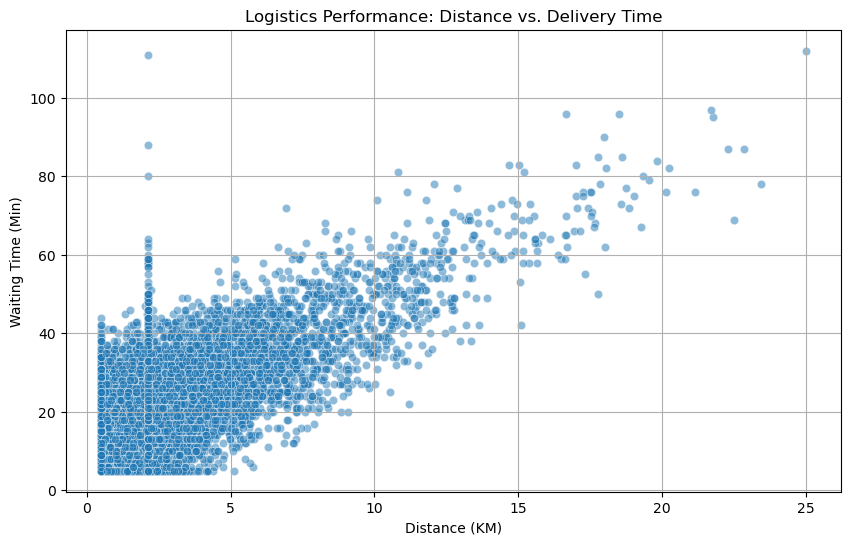

In [9]:
# Visualizing the correlation between distance and waiting time 
# to identify logistics efficiency vs. external bottlenecks
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Jarak_Kirim_KM', y='Waktu_Tunggu_Menit', alpha=0.5)
plt.title('Logistics Performance: Distance vs. Delivery Time')
plt.xlabel('Distance (KM)')
plt.ylabel('Waiting Time (Min)')
plt.grid(True)
plt.savefig('../outputs/distance_vs_time.png', dpi=300, bbox_inches='tight')
plt.show()

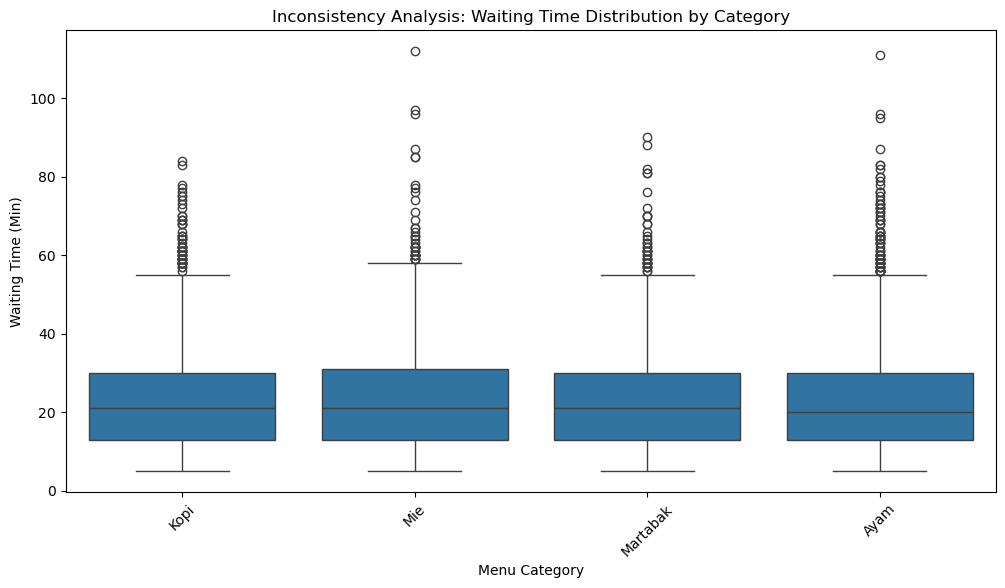

In [14]:
# Analyzing variance and outliers in waiting time across menu categories
# to detect preparation inconsistencies.
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='Kategori_Menu', y='Waktu_Tunggu_Menit', legend=False)
plt.title('Inconsistency Analysis: Waiting Time Distribution by Category')
plt.xlabel('Menu Category')
plt.ylabel('Waiting Time (Min)')
plt.xticks(rotation=45) # Improved readability for category names
plt.savefig('../outputs/waiting_time_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

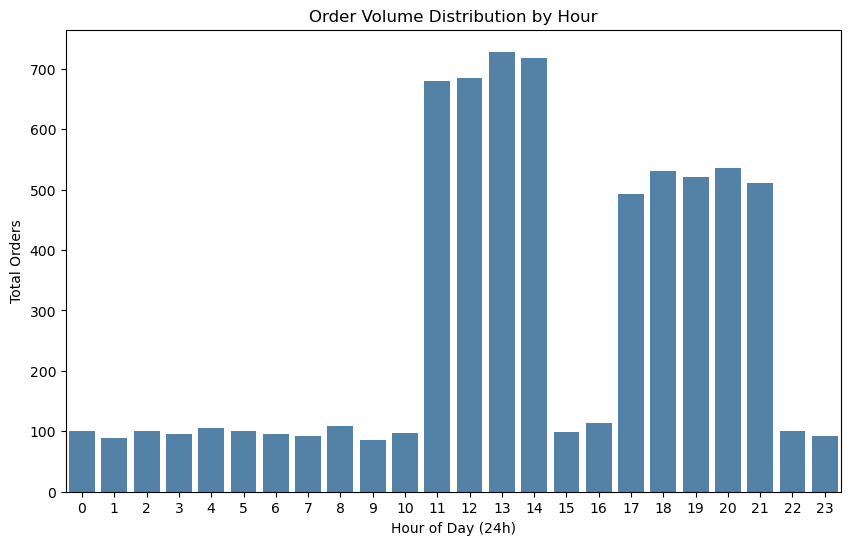

In [10]:
# Distribution of orders across the day to identify peak demand periods
plt.figure(figsize=(10,6))
sns.countplot(data=df_clean, x='Hour', color='steelblue')
plt.title('Order Volume Distribution by Hour')
plt.xlabel('Hour of Day (24h)')
plt.ylabel('Total Orders')
plt.savefig('../outputs/hourly_order_volume.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
# 4. Deep Dive: Peak Hour Impact on Delivery Categories
# Generating a heatmap to analyze operational bottlenecks during peak hours
pivot_table = df_clean.pivot_table(
    index='Hour', 
    columns='Kategori_Menu', 
    values='Waktu_Tunggu_Menit', 
    aggfunc='mean'
)

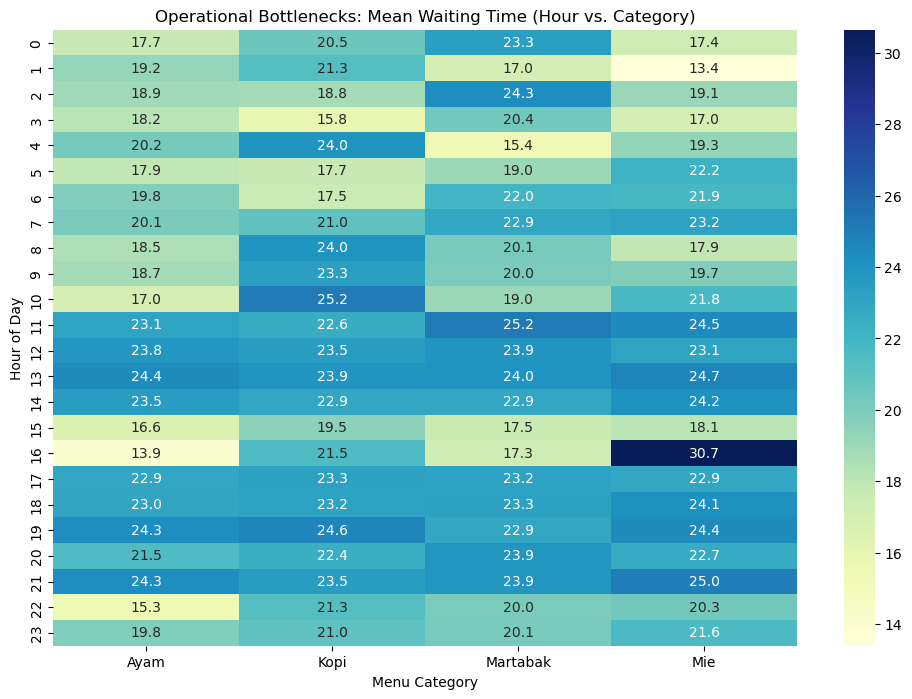

In [12]:
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='.1f')
plt.title('Operational Bottlenecks: Mean Waiting Time (Hour vs. Category)')
plt.xlabel('Menu Category')
plt.ylabel('Hour of Day')
plt.savefig('../outputs/waiting_time_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()